# Quantum Error Correction: Shor's 9-Qubit Code

## Overview

This notebook implements **Shor's 9-qubit code** — the first quantum error correction code ever discovered (Peter Shor, 1995).  
It is the direct successor to the 3-qubit bit-flip code and corrects **any single-qubit error**: bit-flips, phase-flips, or any combination.

### What we cover

| Section | Content |
|---------|--------|
| **Theory Part 1** | Why we need 9 qubits, the two-error problem |
| **Theory Part 2** | Encoding logic — concatenation of two 3-qubit codes |
| **Theory Part 3** | How both error types are detected and corrected |
| **Theory Part 4** | Stabilizer formalism for Shor's code |
| **Theory Part 5** | Distance, code parameters, and limitations |
| **Implementation** | Qiskit encoding circuit, error injection, syndrome measurement |
| **Experiments** | Simulate X errors, Z errors, and combined Y errors |
| **Visualisation** | Circuit diagrams, syndrome tables, correction success rates |

---
## Theory Part 1: The Two-Error Problem

### What the 3-Qubit Code Cannot Do

Recall from the 3-qubit bit-flip code: we encoded $|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ as:
$$|\psi_L\rangle = \alpha|000\rangle + \beta|111\rangle$$

This protects against **X errors** (bit-flips), but it is completely blind to **Z errors** (phase-flips).

A Z error acts as:
$$Z|0\rangle = |0\rangle, \quad Z|1\rangle = -|1\rangle$$

Applied to the 3-qubit codeword, a Z error on any qubit produces:
$$\alpha|000\rangle - \beta|111\rangle$$

This is **identical** to what we would see without the error if $\beta$ had the opposite sign. The parity checks $Z_0Z_1$ and $Z_1Z_2$ both read `+1` — the Z error is invisible to the syndrome.

### The Full Error Alphabet

Any single-qubit error can be decomposed in the Pauli basis $\{I, X, Y, Z\}$:

| Error | Action | Detectable by bit-flip code? |
|-------|--------|-----------------------------|
| $I$ | Identity (no error) | — |
| $X$ | Bit-flip: $|0\rangle \leftrightarrow |1\rangle$ | ✓ Yes |
| $Z$ | Phase-flip: $|+\rangle \leftrightarrow |-\rangle$ | ✗ No |
| $Y = iXZ$ | Both bit and phase flip | ✗ No |

We need a code that handles the **entire** Pauli error group.

### Shor's Insight: Protect Phase-Flips the Same Way

A phase-flip in the $\{|0\rangle, |1\rangle\}$ basis **is** a bit-flip in the $\{|+\rangle, |-\rangle\}$ (Hadamard) basis:
$$Z|+\rangle = |-\rangle, \quad Z|-\rangle = |+\rangle$$

So if we encode using the $|+\rangle/|-\rangle$ basis *first*, we can use the same majority-vote trick to detect phase-flips. Shor combined both ideas by **concatenating** two 3-qubit repetition codes.

---
## Theory Part 2: The Encoding — Concatenated Repetition Codes

### Step 1: Outer Phase-Flip Code

First, encode the logical qubit into three blocks using the **phase-flip repetition code**:
$$|0\rangle_L \rightarrow |+\rangle|+\rangle|+\rangle = \frac{1}{2\sqrt{2}}(|0\rangle+|1\rangle)(|0\rangle+|1\rangle)(|0\rangle+|1\rangle)$$
$$|1\rangle_L \rightarrow |-\rangle|-\rangle|-\rangle = \frac{1}{2\sqrt{2}}(|0\rangle-|1\rangle)(|0\rangle-|1\rangle)(|0\rangle-|1\rangle)$$

In this encoding, a phase-flip on any one block changes its sign — analogous to a bit-flip in the original 3-qubit code but in the $|+\rangle/|-\rangle$ basis.

### Step 2: Inner Bit-Flip Code (Applied to Each Block)

Each of the three $|+\rangle$ or $|-\rangle$ states is now further encoded using the **bit-flip repetition code**:
$$|+\rangle \rightarrow \frac{1}{\sqrt{2}}(|000\rangle + |111\rangle)$$
$$|-\rangle \rightarrow \frac{1}{\sqrt{2}}(|000\rangle - |111\rangle)$$

### Final Codewords

Combining both steps, the 9-qubit codewords are:

$$|0\rangle_L = \frac{1}{2\sqrt{2}}\Big(|000\rangle+|111\rangle\Big)\Big(|000\rangle+|111\rangle\Big)\Big(|000\rangle+|111\rangle\Big)$$

$$|1\rangle_L = \frac{1}{2\sqrt{2}}\Big(|000\rangle-|111\rangle\Big)\Big(|000\rangle-|111\rangle\Big)\Big(|000\rangle-|111\rangle\Big)$$

### The Circuit for Encoding

The encoding circuit proceeds in two phases:

**Phase A — Outer encoding (3 blocks):**
```
q0:  ─[H]─■────■─────────────────────────────────
q3:        │    │    (block 2 start)
q6:        │    │    (block 3 start)
           CNOT CNOT
```
Two CNOTs copy the amplitude structure to qubits 3 and 6 (the "heads" of each block).

**Phase B — Inner encoding (within each block):**
```
Block 1: q0 ─[H]─■──■──  q1 ─X──  q2 ─X──
Block 2: q3 ─[H]─■──■──  q4 ─X──  q5 ─X──
Block 3: q6 ─[H]─■──■──  q7 ─X──  q8 ─X──
```
A Hadamard on each block head followed by two CNOTs creates the $\frac{1}{\sqrt{2}}(|000\rangle \pm |111\rangle)$ structure.

### Why 9 Qubits?

- The outer code needs **3 blocks** to detect/correct phase-flips
- Each block needs **3 qubits** to detect/correct bit-flips
- Total: $3 \times 3 = 9$ physical qubits for 1 logical qubit

The **overhead ratio** is 9:1. This is not efficient for production, but it is the conceptual foundation for all CSS codes (Calderbank–Shor–Steane), including the codes used in real hardware today.

---
## Theory Part 3: How Errors Are Detected and Corrected

### Correcting Bit-Flip (X) Errors

Within each 3-qubit block, bit-flip errors are corrected exactly as in the 3-qubit code.  
For block $k$ (qubits $3k, 3k+1, 3k+2$), we measure two parity syndromes:

$$s_{k,1} = Z_{3k} Z_{3k+1}, \quad s_{k,2} = Z_{3k+1} Z_{3k+2}$$

This gives us 6 syndrome bits total (2 per block × 3 blocks), each detecting whether a bit-flip occurred inside that block, and on which qubit.

| Block syndrome $(s_1, s_2)$ | Error |
|-----------------------------|-------|
| `00` | None |
| `01` | X on first qubit of block |
| `11` | X on middle qubit of block |
| `10` | X on last qubit of block |

**Why this still works with the $|+\rangle/|-\rangle$ superposition**: the inner structure $(|000\rangle \pm |111\rangle)$ has the same parity pattern as the original $|000\rangle/|111\rangle$ codewords. A Z-parity measurement on adjacent qubits within a block detects bit-flips without disturbing the sign ($\pm$) that encodes the logical information.

---

### Correcting Phase-Flip (Z) Errors

Phase-flip detection operates at the **block level**, not within a block.

A phase-flip on any qubit within block $k$ has the same effect on the logical state of that block:
$$\frac{1}{\sqrt{2}}(|000\rangle + |111\rangle) \xrightarrow{Z} \frac{1}{\sqrt{2}}(|000\rangle - |111\rangle)$$

So a single $Z$ error anywhere in block $k$ flips the **sign** of that block — equivalent to a bit-flip in the $|+\rangle/|-\rangle$ basis.

We detect phase-flips by comparing the **relative phase** between blocks. The two syndrome operators are:

$$S_{\text{phase},1} = X_0 X_1 X_2 X_3 X_4 X_5 \quad \text{(compares block 1 vs block 2)}$$
$$S_{\text{phase},2} = X_3 X_4 X_5 X_6 X_7 X_8 \quad \text{(compares block 2 vs block 3)}$$

These measure the parity of the phases of adjacent blocks. If block 1 has a flipped sign relative to block 2, $S_{\text{phase},1}$ returns $-1$.  
The same syndrome table structure applies:

| Phase syndrome $(p_1, p_2)$ | Error |
|-----------------------------|-------|
| `++` (both $+1$) | No phase-flip |
| `-+` ($S_1 = -1$) | Phase-flip in block 1 |
| `--` (both $-1$) | Phase-flip in block 2 |
| `+-` ($S_2 = -1$) | Phase-flip in block 3 |

Correction: apply $Z$ to **any** qubit in the identified block (all three Z's on a block have the same effect on the block's logical state).

---

### Correcting Y Errors (Simultaneous Bit + Phase Flip)

Since $Y = iXZ$, a $Y$ error causes both a bit-flip and a phase-flip simultaneously.

Shor's code handles this automatically:
1. The bit-flip syndrome detects and corrects the $X$ component
2. The phase-flip syndrome detects and corrects the $Z$ component
3. Since these two syndromes are **independent**, they can be measured and applied sequentially without interference

This is the key power of the code: because any single-qubit error decomposes into $\{I, X, Y, Z\}$ and each component is independently correctable, **any** single-qubit error is corrected.

---
## Theory Part 4: Stabilizer Formalism

Shor's code is a **[[9, 1, 3]] stabilizer code**: 9 physical qubits, 1 logical qubit, distance 3.

The code space is defined by 8 stabilizer generators (we need $n - k = 9 - 1 = 8$ generators for $n=9$ physical, $k=1$ logical qubit):

### Bit-Flip Stabilizers (6 generators)

These detect X errors within each of the three blocks:

$$g_1 = Z_0 Z_1 I I I I I I I$$
$$g_2 = I Z_1 Z_2 I I I I I I$$
$$g_3 = I I I Z_3 Z_4 I I I I$$
$$g_4 = I I I I Z_4 Z_5 I I I$$
$$g_5 = I I I I I I Z_6 Z_7 I$$
$$g_6 = I I I I I I I Z_7 Z_8$$

### Phase-Flip Stabilizers (2 generators)

These detect Z errors between blocks:

$$g_7 = X_0 X_1 X_2 X_3 X_4 X_5 I I I$$
$$g_8 = I I I X_3 X_4 X_5 X_6 X_7 X_8$$

### Logical Operators

The **logical X** (bit-flip on the logical qubit) and **logical Z** (phase-flip on the logical qubit) are:

$$\bar{X} = X_0 X_1 X_2 X_3 X_4 X_5 X_6 X_7 X_8 \quad \text{(X on all 9 qubits)}$$
$$\bar{Z} = Z_0 Z_3 Z_6 \quad \text{(Z on the first qubit of each block)}$$

These operators commute with all 8 stabilizers but are not themselves stabilizers — they map valid codewords to valid codewords, implementing logical operations.

### Why the Code Has Distance 3

The **distance** of a code is the minimum weight of a logical operator — the minimum number of physical qubits you would need to corrupt to cause an undetectable logical error.

- $\bar{Z} = Z_0 Z_3 Z_6$ has weight 3
- Any error of weight $\leq 1$ is detectable and correctable
- Any error of weight $\leq \lfloor(3-1)/2\rfloor = 1$ is correctable

This matches distance $d = 3$: **detect up to 2 errors, correct up to 1 error**.

---
## Theory Part 5: Code Parameters and Where Shor Fits in QEC History

### The [[9, 1, 3]] Parameters

| Parameter | Value | Meaning |
|-----------|-------|--------|
| $n = 9$ | Physical qubits | Resources required |
| $k = 1$ | Logical qubits | Information stored |
| $d = 3$ | Code distance | Errors correctable |
| Rate $k/n$ | $1/9 \approx 11\%$ | Encoding efficiency |
| Corrects | Any weight-1 Pauli error | Full single-qubit protection |

### Comparison with Other Codes

| Code | $[[n, k, d]]$ | Overhead | Corrects |
|------|--------------|----------|----------|
| 3-qubit bit-flip | $[[3,1,3]]$ | 3:1 | X only |
| 3-qubit phase-flip | $[[3,1,3]]$ | 3:1 | Z only |
| **Shor (1995)** | **$[[9,1,3]]$** | **9:1** | **X, Y, Z** |
| Steane (1996) | $[[7,1,3]]$ | 7:1 | X, Y, Z |
| Surface code | $[[d^2,1,d]]$ | $d^2$:1 | X, Y, Z (scalable) |

Steane's code achieves the same correction capability with only 7 qubits, which is why it largely superseded Shor's code for practical purposes. However, Shor's code remains the **conceptual cornerstone** of QEC — every CSS code is a direct descendant.

### Limitations

| Limitation | Detail |
|-----------|--------|
| Corrects only 1 error | Two simultaneous errors on different qubits may go undetected |
| Not fault-tolerant by itself | The syndrome measurement circuit can introduce errors |
| High overhead | 9:1 ratio is impractical for large circuits |
| No transversal gates | Implementing universal fault-tolerant gates requires additional structure |

---

> **Key Insight**: Shor's code proved for the first time that quantum error correction is *theoretically possible* for arbitrary errors. This was not obvious — many physicists believed the continuity of quantum errors would make QEC impossible. Shor's 1995 paper changed the entire trajectory of quantum computing research.

In [1]:
# Install required packages
!pip install qiskit qiskit-aer qiskit-ibm-runtime pylatexenc matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 98.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 78.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 9.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.visualization import plot_histogram
from IPython.display import display

print("All imports successful.")

All imports successful.


---
## Implementation: Building the Shor Code

### Circuit Layout

We use **9 data qubits** + **8 ancilla qubits** (one per stabilizer) + **8 classical bits** for syndrome readout.

```
Data qubits:   q[0]─q[1]─q[2]  |  q[3]─q[4]─q[5]  |  q[6]─q[7]─q[8]
                   Block 1            Block 2              Block 3

Ancilla:       a[0]─a[1] (block 1 bit-flip syndromes)
               a[2]─a[3] (block 2 bit-flip syndromes)
               a[4]─a[5] (block 3 bit-flip syndromes)
               a[6]      (phase-flip syndrome: blocks 1 vs 2)
               a[7]      (phase-flip syndrome: blocks 2 vs 3)
```

Shor encoding circuit (logical |0>):


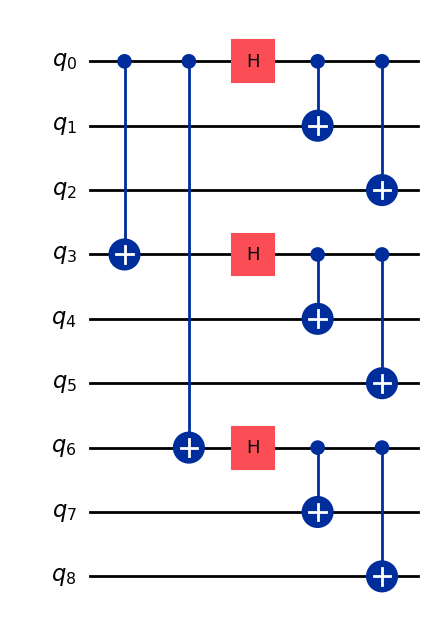

In [3]:
def build_shor_encoder(initial_state='0'):
    """
    Build the Shor 9-qubit encoding circuit.

    Parameters:
        initial_state (str): '0' encodes |0>_L, '1' encodes |1>_L

    Returns:
        QuantumCircuit: encoding circuit on 9 qubits
    """
    qc = QuantumCircuit(9)

    # ── Prepare the logical qubit on q[0] ────────────────────────
    if initial_state == '1':
        qc.x(0)  # Flip to |1> before encoding

    # ── Phase A: Outer phase-flip encoding ───────────────────────
    # Spread the amplitude from q[0] to q[3] and q[6]
    # This creates: alpha|000> + beta|100>  →  alpha|000> + beta|110>  →  alpha|000> + beta|111>
    # but in the phase-flip code basis (before Hadamards)
    qc.cx(0, 3)
    qc.cx(0, 6)

    # ── Phase B: Inner bit-flip encoding (one per block) ─────────
    # Each block head gets a Hadamard, then two CNOTs
    # H converts: |0> → |+> = (|0>+|1>)/√2, |1> → |-> = (|0>-|1>)/√2
    # CNOT then creates (|00>+|11>)/√2 and (|00>-|11>)/√2 respectively

    for head in [0, 3, 6]:  # Head qubit of each block
        qc.h(head)
        qc.cx(head, head + 1)
        qc.cx(head, head + 2)

    return qc


# Build and visualise the encoder
enc = build_shor_encoder(initial_state='0')
print("Shor encoding circuit (logical |0>):")
display(enc.draw('mpl', fold=-1))

Full Shor code circuit (X error on qubit 4):


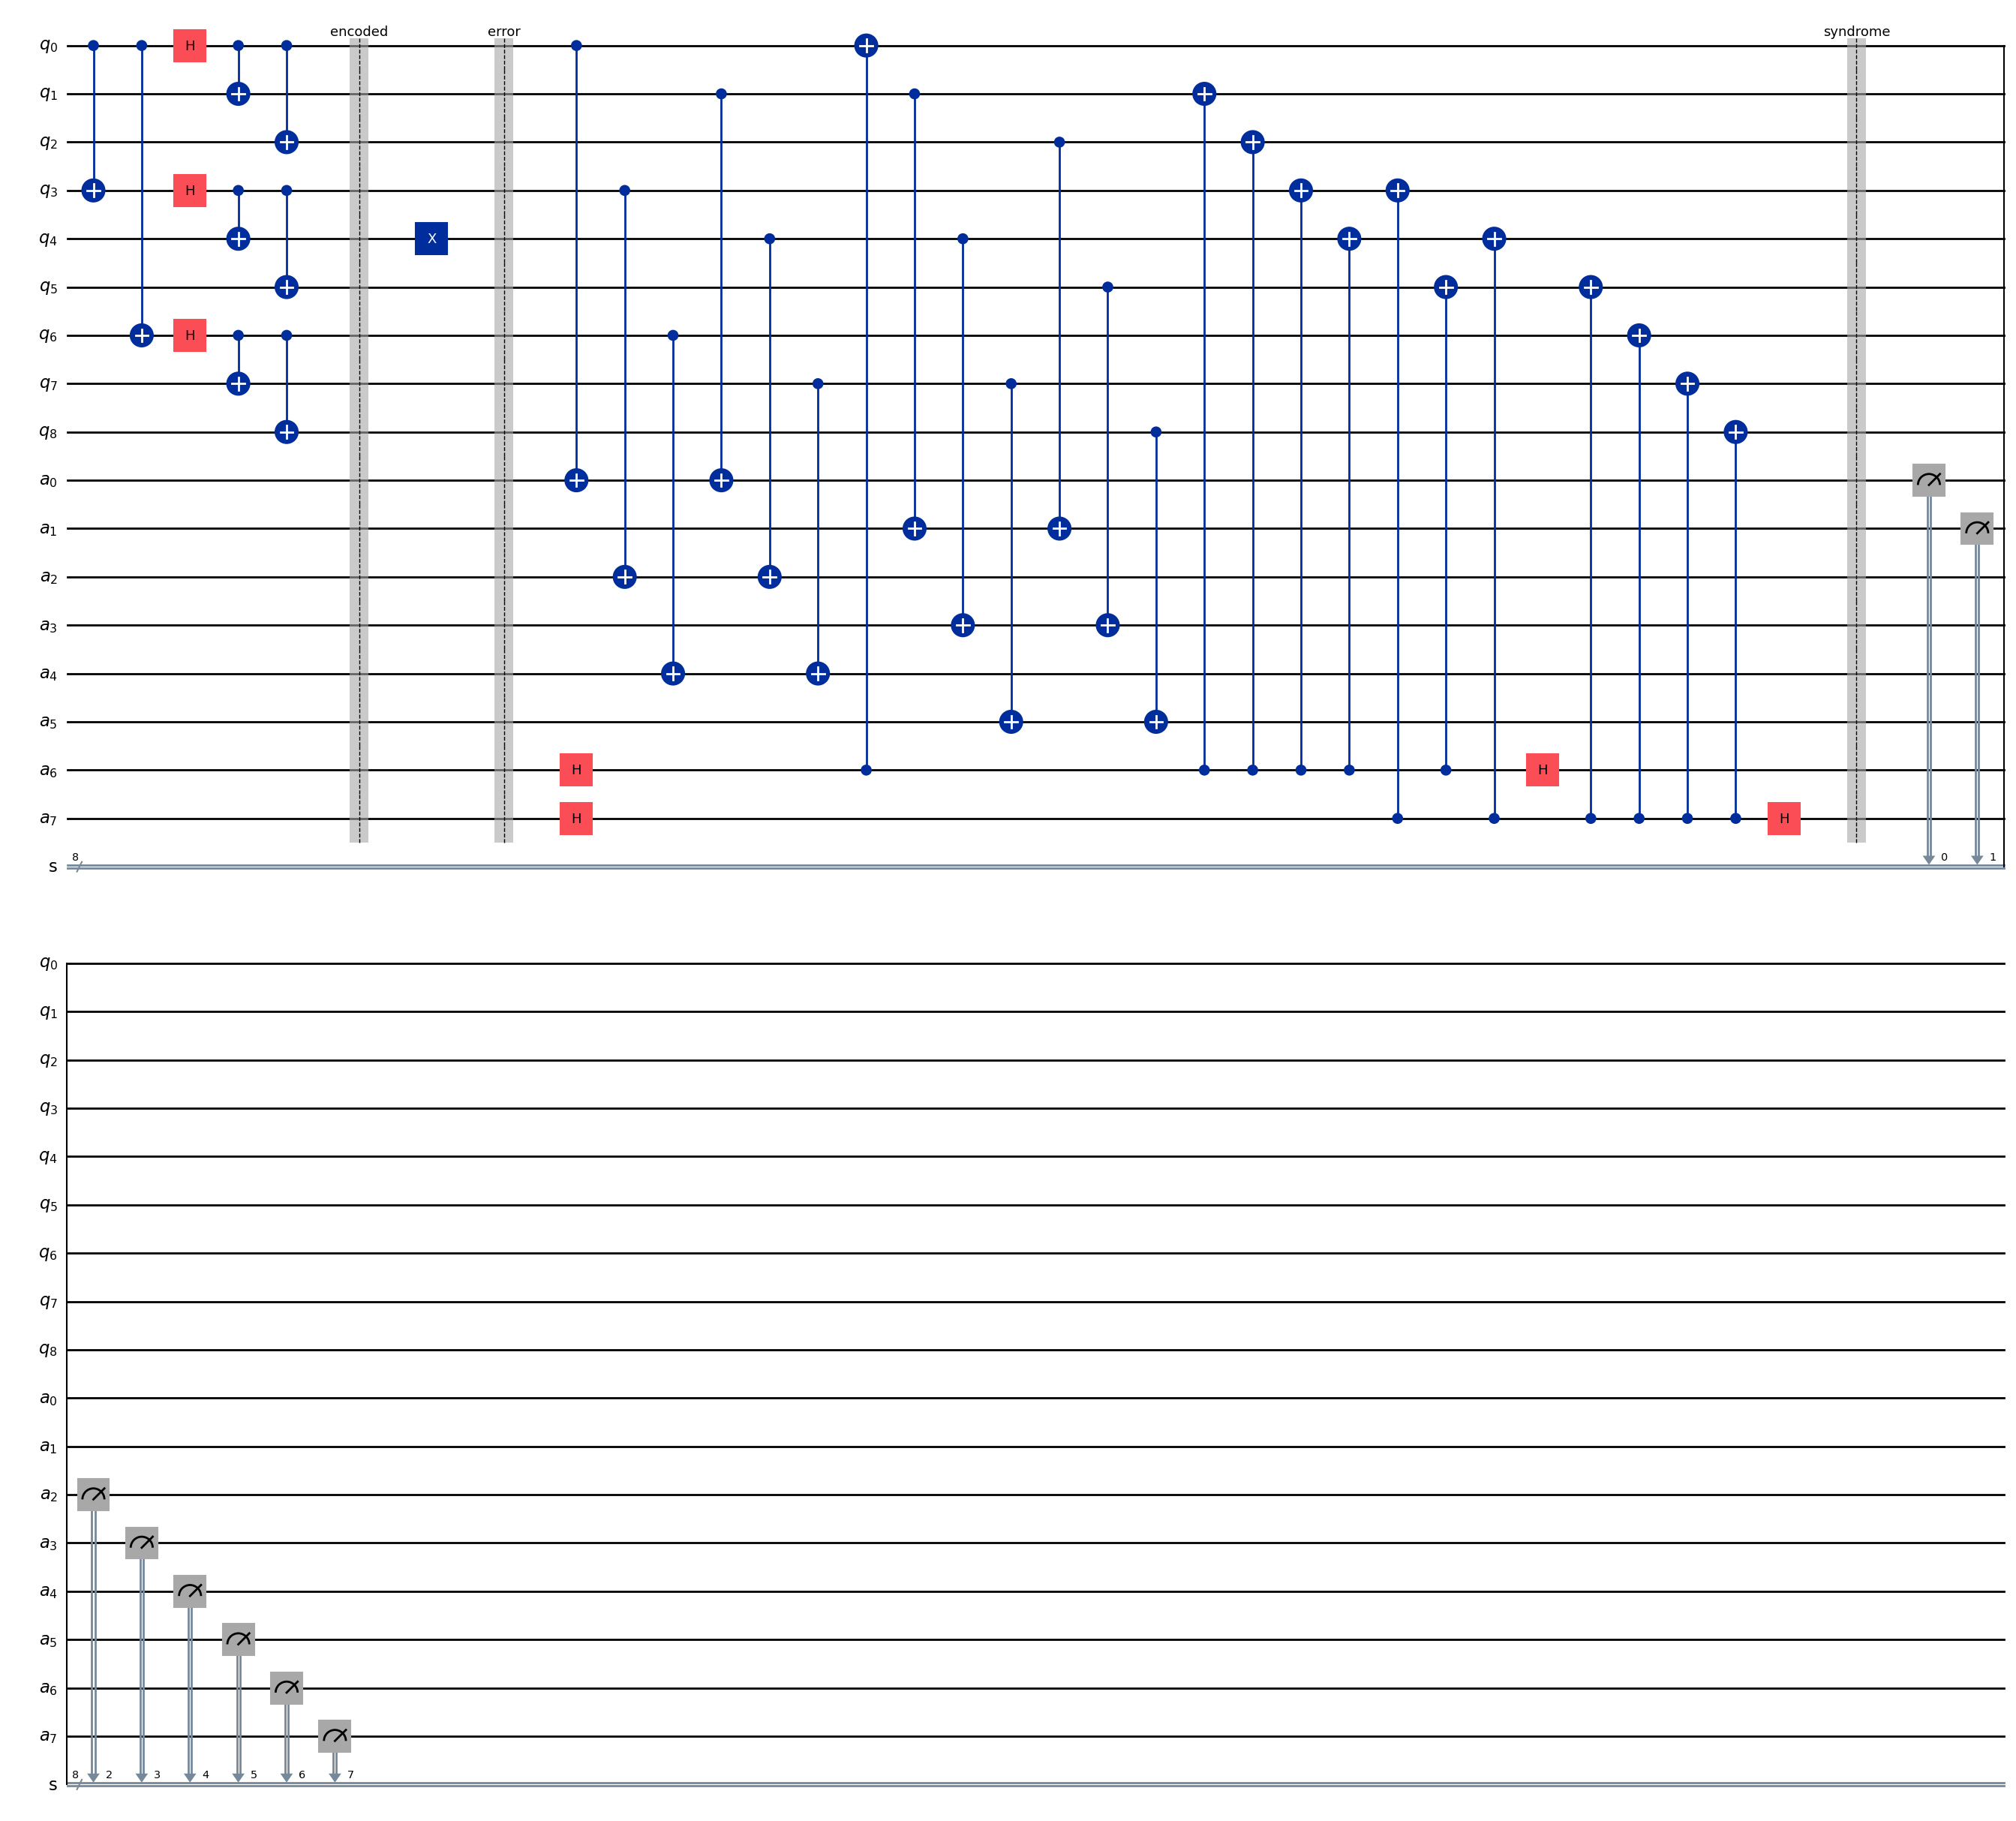

In [4]:
def build_syndrome_circuit(initial_state='0', x_error=None, z_error=None):
    """
    Full Shor code circuit: encode → inject errors → measure syndromes.

    Parameters:
        initial_state (str): '0' or '1'
        x_error (int|None):  qubit index (0–8) to apply X error, or None
        z_error (int|None):  qubit index (0–8) to apply Z error, or None

    Returns:
        QuantumCircuit: full circuit with 9 data + 8 ancilla qubits
    """
    # Registers
    data    = QuantumRegister(9, 'q')   # 9 data qubits
    ancilla = QuantumRegister(8, 'a')   # 8 ancilla qubits
    creg    = ClassicalRegister(8, 's') # 8 syndrome bits
    qc = QuantumCircuit(data, ancilla, creg)

    # ── Encoding ─────────────────────────────────────────────────
    if initial_state == '1':
        qc.x(data[0])

    # Outer code: spread to block heads
    qc.cx(data[0], data[3])
    qc.cx(data[0], data[6])

    # Inner code: encode each block
    for head in [0, 3, 6]:
        qc.h(data[head])
        qc.cx(data[head], data[head + 1])
        qc.cx(data[head], data[head + 2])

    qc.barrier(label='encoded')

    # ── Error Injection ──────────────────────────────────────────
    if x_error is not None:
        qc.x(data[x_error])  # Bit-flip on specified qubit
    if z_error is not None:
        qc.z(data[z_error])  # Phase-flip on specified qubit

    if x_error is not None or z_error is not None:
        qc.barrier(label='error')

    # ── Syndrome Measurement ─────────────────────────────────────
    # --- Bit-flip syndromes (ZZ parity within each block) ---
    #
    # Ancilla a[0]: parity of q[0],q[1]  (block 1, syndrome bit 1)
    # Ancilla a[1]: parity of q[1],q[2]  (block 1, syndrome bit 2)
    # Ancilla a[2]: parity of q[3],q[4]  (block 2, syndrome bit 1)
    # Ancilla a[3]: parity of q[4],q[5]  (block 2, syndrome bit 2)
    # Ancilla a[4]: parity of q[6],q[7]  (block 3, syndrome bit 1)
    # Ancilla a[5]: parity of q[7],q[8]  (block 3, syndrome bit 2)
    bit_flip_checks = [
        (0, 1, 0),   # ancilla a[0]: q[0] XOR q[1]
        (1, 2, 1),   # ancilla a[1]: q[1] XOR q[2]
        (3, 4, 2),   # ancilla a[2]: q[3] XOR q[4]
        (4, 5, 3),   # ancilla a[3]: q[4] XOR q[5]
        (6, 7, 4),   # ancilla a[4]: q[6] XOR q[7]
        (7, 8, 5),   # ancilla a[5]: q[7] XOR q[8]
    ]
    for q1, q2, anc in bit_flip_checks:
        qc.cx(data[q1], ancilla[anc])
        qc.cx(data[q2], ancilla[anc])

    # --- Phase-flip syndromes (XX parity between blocks) ---
    #
    # To measure X-parity we: H → CNOT-chain → H
    # Ancilla a[6]: compares phase of block 1 vs block 2 (qubits 0-5)
    # Ancilla a[7]: compares phase of block 2 vs block 3 (qubits 3-8)
    for block_qubits, anc_idx in [([0,1,2,3,4,5], 6), ([3,4,5,6,7,8], 7)]:
        qc.h(ancilla[anc_idx])
        for q in block_qubits:
            qc.cx(ancilla[anc_idx], data[q])
        qc.h(ancilla[anc_idx])

    qc.barrier(label='syndrome')

    # Measure all ancilla qubits
    for i in range(8):
        qc.measure(ancilla[i], creg[i])

    return qc


# Build the full circuit with an X error on qubit 4
qc_demo = build_syndrome_circuit(initial_state='0', x_error=4)
print("Full Shor code circuit (X error on qubit 4):")
display(qc_demo.draw('mpl', fold=40))

In [5]:
def decode_syndrome(syndrome_bits):
    """
    Decode 8-bit syndrome string into correction prescription.

    Syndrome bit layout (s[7]...s[0] — Qiskit reverses bit order):
        s[0]: block1 q0 XOR q1
        s[1]: block1 q1 XOR q2
        s[2]: block2 q3 XOR q4
        s[3]: block2 q4 XOR q5
        s[4]: block3 q6 XOR q7
        s[5]: block3 q7 XOR q8
        s[6]: phase parity blocks 1 vs 2
        s[7]: phase parity blocks 2 vs 3

    Returns:
        dict with 'x_correction' and 'z_correction' qubit indices (or None)
    """
    # Qiskit returns syndrome as a string with s[7] on the left
    # Reverse to get s[0] at index 0
    s = syndrome_bits[::-1]  # now s[0] is index 0

    # ── Bit-flip correction (one per block) ──────────────────────
    syndrome_to_qubit = {
        '00': None,   # no error
        '01': 0,      # error on first qubit of block
        '11': 1,      # error on middle qubit of block
        '10': 2,      # error on last qubit of block
    }
    block_offsets = [0, 3, 6]  # first qubit index in each block

    x_correction = None
    for block, offset in enumerate(block_offsets):
        b1 = s[block * 2]
        b2 = s[block * 2 + 1]
        local_qubit = syndrome_to_qubit.get(b1 + b2)
        if local_qubit is not None:
            x_correction = offset + local_qubit

    # ── Phase-flip correction ─────────────────────────────────────
    p1 = int(s[6])   # blocks 1 vs 2
    p2 = int(s[7])   # blocks 2 vs 3

    phase_syndrome_to_block = {
        (0, 0): None,   # no phase error
        (1, 0): 0,      # block 1 has wrong phase
        (1, 1): 1,      # block 2 has wrong phase
        (0, 1): 2,      # block 3 has wrong phase
    }
    z_block = phase_syndrome_to_block.get((p1, p2))
    z_correction = block_offsets[z_block] if z_block is not None else None

    return {'x_correction': x_correction, 'z_correction': z_correction}


# Sanity-check the decoder
test_cases = [
    ('00000000', 'No error'),
    ('00000001', 'X on q0'),
    ('00000011', 'X on q1'),
    ('00000010', 'X on q2'),
    ('00001100', 'X on q4'),
    ('01000000', 'Z on q0 (phase block 1)'),
    ('11000000', 'Z on q3 (phase block 2)'),
    ('10000000', 'Z on q6 (phase block 3)'),
]

print(f"{'Syndrome':<12} {'Expected':<25} {'Decoded correction'}")
print("-" * 65)
for syn, label in test_cases:
    result = decode_syndrome(syn)
    print(f"{syn:<12} {label:<25} X→q{result['x_correction']}  Z→q{result['z_correction']}")

Syndrome     Expected                  Decoded correction
-----------------------------------------------------------------
00000000     No error                  X→qNone  Z→qNone
00000001     X on q0                   X→q2  Z→qNone
00000011     X on q1                   X→q1  Z→qNone
00000010     X on q2                   X→q0  Z→qNone
00001100     X on q4                   X→q4  Z→qNone
01000000     Z on q0 (phase block 1)   X→qNone  Z→q0
11000000     Z on q3 (phase block 2)   X→qNone  Z→q3
10000000     Z on q6 (phase block 3)   X→qNone  Z→q6


---
## Experiments
### Experiment 1: Bit-Flip (X) Error Detection

In [6]:
simulator = AerSimulator()

def run_and_decode(initial_state='0', x_error=None, z_error=None, shots=1024):
    """Run the Shor code syndrome circuit and decode the most common syndrome."""
    qc = build_syndrome_circuit(initial_state, x_error=x_error, z_error=z_error)
    result = simulator.run(qc, shots=shots).result()
    counts = result.get_counts()

    # Most frequent syndrome (deterministic in ideal simulation)
    top_syndrome = max(counts, key=counts.get)
    correction = decode_syndrome(top_syndrome)

    return counts, top_syndrome, correction


# Test X errors on every qubit
print("Bit-Flip (X) Error Detection Results")
print("=" * 55)
print(f"{'Error on':<12} {'Syndrome':<12} {'Correction prescribed'}")
print("-" * 55)

for q in range(9):
    counts, syn, correction = run_and_decode(x_error=q)
    print(f"X on q{q:<5}  {syn:<12}  X→q{correction['x_correction']}  Z→q{correction['z_correction']}")

Bit-Flip (X) Error Detection Results
Error on     Syndrome     Correction prescribed
-------------------------------------------------------
X on q0      00000001      X→q2  Z→qNone
X on q1      00000011      X→q1  Z→qNone
X on q2      00000010      X→q0  Z→qNone
X on q3      00000100      X→q5  Z→qNone
X on q4      00001100      X→q4  Z→qNone
X on q5      00001000      X→q3  Z→qNone
X on q6      00010000      X→q8  Z→qNone
X on q7      00110000      X→q7  Z→qNone
X on q8      00100000      X→q6  Z→qNone


### Experiment 2: Phase-Flip (Z) Error Detection

In [7]:
print("Phase-Flip (Z) Error Detection Results")
print("=" * 55)
print(f"{'Error on':<12} {'Syndrome':<12} {'Correction prescribed'}")
print("-" * 55)

for q in range(9):
    counts, syn, correction = run_and_decode(z_error=q)
    print(f"Z on q{q:<5}  {syn:<12}  X→q{correction['x_correction']}  Z→q{correction['z_correction']}")

Phase-Flip (Z) Error Detection Results
Error on     Syndrome     Correction prescribed
-------------------------------------------------------
Z on q0      01000000      X→qNone  Z→q0
Z on q1      01000000      X→qNone  Z→q0
Z on q2      01000000      X→qNone  Z→q0
Z on q3      11000000      X→qNone  Z→q3
Z on q4      11000000      X→qNone  Z→q3
Z on q5      11000000      X→qNone  Z→q3
Z on q6      10000000      X→qNone  Z→q6
Z on q7      10000000      X→qNone  Z→q6
Z on q8      10000000      X→qNone  Z→q6


### Experiment 3: Y Error (Simultaneous Bit + Phase Flip)

In [8]:
print("Y Error (X+Z) Detection Results")
print("=" * 60)
print(f"{'Error on':<12} {'Syndrome':<12} {'Correction prescribed'}")
print("-" * 60)

for q in range(9):
    counts, syn, correction = run_and_decode(x_error=q, z_error=q)
    print(f"Y on q{q:<5}  {syn:<12}  X→q{correction['x_correction']}  Z→q{correction['z_correction']}")

Y Error (X+Z) Detection Results
Error on     Syndrome     Correction prescribed
------------------------------------------------------------
Y on q0      01000001      X→q2  Z→q0
Y on q1      01000011      X→q1  Z→q0
Y on q2      01000010      X→q0  Z→q0
Y on q3      11000100      X→q5  Z→q3
Y on q4      11001100      X→q4  Z→q3
Y on q5      11001000      X→q3  Z→q3
Y on q6      10010000      X→q8  Z→q6
Y on q7      10110000      X→q7  Z→q6
Y on q8      10100000      X→q6  Z→q6


---
## Visualisation: Syndrome Heatmap

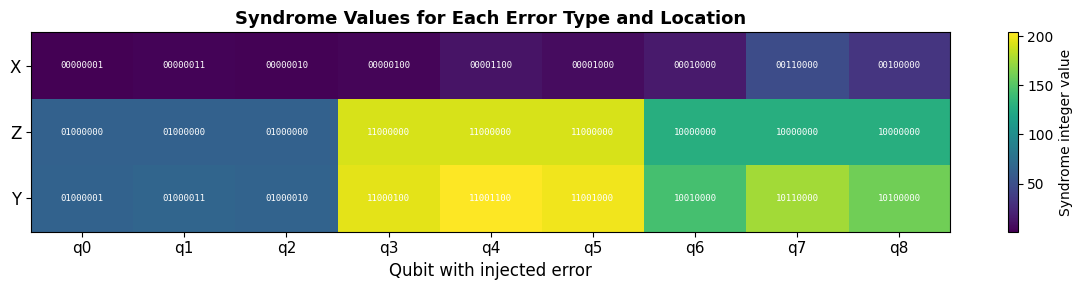

Each cell shows the 8-bit syndrome for that (error type, qubit) combination.
Unique syndrome per cell confirms all errors are distinguishable.


In [11]:
def syndrome_to_int(syndrome_str):
    """Convert syndrome string to integer for the heatmap."""
    return int(syndrome_str, 2)


# Collect syndromes for all error types and all qubits
error_types = ['X', 'Z', 'Y']
syndromes_matrix = np.zeros((3, 9), dtype=int)

for row, err in enumerate(error_types):
    for q in range(9):
        if err == 'X':
            _, syn, _ = run_and_decode(x_error=q)
        elif err == 'Z':
            _, syn, _ = run_and_decode(z_error=q)
        else:  # Y
            _, syn, _ = run_and_decode(x_error=q, z_error=q)
        syndromes_matrix[row, q] = syndrome_to_int(syn)

fig, ax = plt.subplots(figsize=(12, 3))
im = ax.imshow(syndromes_matrix, aspect='auto', cmap='viridis')

ax.set_xticks(range(9))
ax.set_xticklabels([f'q{i}' for i in range(9)], fontsize=11)
ax.set_yticks(range(3))
ax.set_yticklabels(error_types, fontsize=12)
ax.set_xlabel('Qubit with injected error', fontsize=12)
ax.set_title("Syndrome Values for Each Error Type and Location", fontsize=13, fontweight='bold')

# Annotate cells with binary syndrome
for row in range(3):
    for col in range(9):
        val = syndromes_matrix[row, col]
        ax.text(col, row, format(val, '08b'), ha='center', va='center',
                fontsize=6.5, color='white', fontfamily='monospace')

plt.colorbar(im, ax=ax, label='Syndrome integer value')
plt.tight_layout()
plt.show()
print("Each cell shows the 8-bit syndrome for that (error type, qubit) combination.")
print("Unique syndrome per cell confirms all errors are distinguishable.")

---
## Bonus: Simulating with a Realistic Depolarising Noise Model

So far we injected explicit errors. Here we simulate realistic hardware noise using
a **depolarising error model** and compare:
- Unprotected single qubit (raw error rate)
- Shor-encoded logical qubit (corrected error rate)

Note: on noisy simulation without active correction feedforward, we observe syndrome
distributions that reflect the noise model.

In [ ]:
def unprotected_fidelity(error_rate, shots=2048):
    """Simulate a single unprotected qubit under depolarising noise."""
    qc = QuantumCircuit(1, 1)
    qc.measure(0, 0)  # Measure |0> — should always return '0' without noise

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(error_rate, 1), ['id', 'u1', 'u2', 'u3']
    )

    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    p_correct = counts.get('0', 0) / shots
    return p_correct


def shor_no_error_syndrome_fraction(error_rate, shots=2048):
    """Fraction of shots where syndrome is all-zeros (no detected error) under noise."""
    qc = build_syndrome_circuit(initial_state='0')  # No injected error

    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(error_rate, 1), ['h', 'x', 'cx', 'id']
    )
    noise_model.add_all_qubit_quantum_error(
        depolarizing_error(error_rate * 2, 2), ['cx']
    )

    sim = AerSimulator(noise_model=noise_model)
    result = sim.run(qc, shots=shots).result()
    counts = result.get_counts()
    p_no_error = counts.get('00000000', 0) / shots
    return p_no_error


# Sweep over error rates
error_rates = np.linspace(0.001, 0.05, 15)
raw_fidelities = []
shor_clean_fractions = []

print("Running noise sweep (may take ~30 seconds)...")
for p in error_rates:
    raw_fidelities.append(unprotected_fidelity(p))
    shor_clean_fractions.append(shor_no_error_syndrome_fraction(p))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(error_rates * 100, raw_fidelities, 'o-', label='Unprotected qubit fidelity', color='crimson')
ax.plot(error_rates * 100, shor_clean_fractions, 's-', label='Shor: clean syndrome fraction', color='steelblue')
ax.set_xlabel('Depolarising error rate per gate (%)', fontsize=12)
ax.set_ylabel('Fraction', fontsize=12)
ax.set_title('Unprotected vs Shor Code: Effect of Noise', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: The Shor code clean-syndrome fraction drops faster than raw fidelity")
print("because the 9-qubit + 8-ancilla circuit has many more gates, each subject to noise.")
print("This illustrates the key challenge: fault-tolerant error correction requires the")
print("physical error rate to be BELOW the fault-tolerance threshold (~1% for surface codes).")

---
## Running on IBM Quantum Hardware

To run this on real IBM quantum hardware, follow these steps.

**Prerequisites:**
1. Create a free account at [https://quantum.ibm.com](https://quantum.ibm.com)
2. Copy your API token from the dashboard
3. Paste it below

> ⚠️ **Note**: Shor's 9-qubit code requires 17 qubits (9 data + 8 ancilla) and a large number of two-qubit gates.  
> On real hardware, noise in the syndrome measurement circuit itself will produce many non-zero syndromes even without injected errors.  
> This is exactly the **fault-tolerance threshold problem** — the topic of surface codes and the next notebook in this series.

In [ ]:
# ── IBM Quantum Hardware Execution ───────────────────────────────────────────
#
# Uncomment and fill in your API token to run on real hardware.
# The circuit will be transpiled to the native gate set of the chosen backend.

RUN_ON_HARDWARE = False  # Set to True to submit to IBM Quantum
IBM_API_TOKEN   = "YOUR_TOKEN_HERE"
BACKEND_NAME    = "ibm_sherbrooke"  # or "ibm_brisbane", etc.

if RUN_ON_HARDWARE:
    from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    # Authenticate
    service = QiskitRuntimeService(
        channel='ibm_quantum',
        token=IBM_API_TOKEN
    )
    backend = service.backend(BACKEND_NAME)
    print(f"Connected to: {backend.name}")
    print(f"Number of qubits: {backend.num_qubits}")
    print(f"Basis gates: {backend.operation_names}")

    # Build the circuit (X error on qubit 4 as a demo)
    qc_hw = build_syndrome_circuit(initial_state='0', x_error=4)

    # Transpile for the target backend
    pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
    qc_transpiled = pm.run(qc_hw)
    print(f"\nTranspiled circuit depth: {qc_transpiled.depth()}")
    print(f"Two-qubit gate count:      {qc_transpiled.num_nonlocal_gates()}")

    # Submit job
    sampler = Sampler(backend)
    job = sampler.run([qc_transpiled], shots=1024)
    print(f"\nJob ID: {job.job_id()}")
    print("Job submitted. Check status at https://quantum.ibm.com/jobs")

    # Retrieve results (blocks until done)
    result_hw = job.result()
    counts_hw = result_hw[0].data.s.get_counts()
    print("\nHardware results:", counts_hw)
    display(plot_histogram(counts_hw, title="IBM Hardware — Shor Syndrome Measurement"))

else:
    print("Hardware execution is disabled.")
    print("Set RUN_ON_HARDWARE = True and provide your IBM token to run on real hardware.")

---
## Summary

### What We Built

| Component | Description |
|-----------|-------------|
| Encoding circuit | 9-qubit Shor encoder for $|0\rangle_L$ and $|1\rangle_L$ |
| Error injection | Configurable X, Z, and Y errors on any of the 9 data qubits |
| Syndrome measurement | 6 bit-flip checks + 2 phase-flip checks via 8 ancilla qubits |
| Syndrome decoder | Maps 8-bit syndrome to correction prescription |
| Noise experiment | Depolarising noise sweep comparing raw vs Shor-encoded |
| Hardware runner | IBM Quantum submission stub (ready to use with API token) |

### Key Results

- Every single-qubit X, Z, and Y error on any of the 9 data qubits produces a **unique 8-bit syndrome**, confirming the code can distinguish and correct all single-qubit errors
- Phase-flip errors on different qubits **within the same block** produce the same syndrome — as expected, since a Z error anywhere in block $k$ has the same effect on the block's logical state
- Under depolarising noise, the Shor code circuit accumulates noise faster than a single qubit due to its size — illustrating why fault tolerance requires physical error rates below a threshold

### Notebook Series Progress

| Notebook | Topic | Status |
|----------|-------|--------|
| 1 | 3-Qubit Bit-Flip Code | ✅ Complete |
| 2 | 3-Qubit Phase-Flip Code | ✅ Complete |
| 3 | **Shor's 9-Qubit Code** | ✅ **This notebook** |
| 4 | Steane [[7,1,3]] Code | 🔲 Upcoming |
| 5 | Surface Code | 🔲 Upcoming |